### Setup and imports

In [1]:
import sys
import logging

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

if not logger.handlers:

    console_handler = logging.StreamHandler(sys.stdout)  # ← fix
    file_handler = logging.FileHandler("run.log")

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s"
    )

    console_handler.setFormatter(formatter)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)
logger.info("Loaded logger")

2026-04-28 14:41:27,950 | INFO | Loaded logger


In [2]:
logger.info('Starting setup and imports')

import random
import math
import os, json, time, warnings
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR #baseline
from torchvision import transforms #for iamge preprocessing, e.g. resize, augmentation etc
 
from sklearn.model_selection import GroupShuffleSplit #for lesion_id split later
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)
 
warnings.filterwarnings("ignore")
logger.info("Imports OK")
import subprocess, zipfile

on_aws = True
 
BASE_URL = "https://isic-archive.s3.amazonaws.com/challenges/2019"

'''if on_aws:
    # PATHS 
    uvaid="dpy8wq"
    DATA_ROOT = f"/home/ubuntu/{uvaid}/isic2019"    
    TEST_INPUT = f"{DATA_ROOT}/ISIC_2019_Test_Input"
    TRAIN_INPUT = f"{DATA_ROOT}/ISIC_2019_Training_Input"
    CKPT_DIR  = f"{DATA_ROOT}/checkpoints"
else:
    # PATHS 
    DATA_ROOT = "/scratch/wpl3a/isic2019"
    TEST_INPUT = f"{DATA_ROOT}/ISIC_2019_Test_Input"
    TRAIN_INPUT = f"{DATA_ROOT}/ISIC_2019_Training_Input"
    CKPT_DIR  = "/scratch/wpl3a/isic2019/checkpoints"

os.makedirs(DATA_ROOT, exist_ok=True)'''

# PATHS 

DATA_ROOT = "/scratch/wpl3a/isic2019"
TEST_INPUT = f"{DATA_ROOT}/ISIC_2019_Test_Input"
TRAIN_INPUT = f"{DATA_ROOT}/ISIC_2019_Training_Input"
CKPT_DIR  = "/scratch/wpl3a/isic2019/checkpoints"

os.makedirs(DATA_ROOT, exist_ok=True)


2026-04-28 14:41:27,961 | INFO | Starting setup and imports
2026-04-28 14:41:35,099 | INFO | Imports OK


In [3]:
os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
wandb.login()

logger.info('Setup and imports complete')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wpl3a/.netrc.
wandb: Currently logged in as: wpl3a (vrb9e-university-of-virginia-school-of-data-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


2026-04-28 14:41:35,288 | INFO | Setup and imports complete


### Download and unzip ISIC dataset

In [4]:
# Download CSVs & zips 
DOWNLOADS = [
    (f"{BASE_URL}/ISIC_2019_Training_GroundTruth.csv", f"{DATA_ROOT}/train_gt.csv"),
    (f"{BASE_URL}/ISIC_2019_Training_Metadata.csv",    f"{DATA_ROOT}/train_meta.csv"),
    (f"{BASE_URL}/ISIC_2019_Test_GroundTruth.csv",     f"{DATA_ROOT}/test_gt.csv"),
    (f"{BASE_URL}/ISIC_2019_Training_Input.zip",       f"{DATA_ROOT}/train_imgs.zip"),
    (f"{BASE_URL}/ISIC_2019_Test_Input.zip",           f"{DATA_ROOT}/test_imgs.zip"),
]

# If already downloaded, do not download and unzip!!
if not len([f for f in os.listdir(TEST_INPUT) if f.endswith('.jpg')]) == 8238 and \
    len([f for f in os.listdir(TRAIN_INPUT) if f.endswith('.jpg')]) == 25331:
    for url, dest in DOWNLOADS:
            logger.info(f"Downloading {os.path.basename(dest)} ...")
            subprocess.run(
                ["curl", "--location", "--progress-bar",
                 "--retry", "3", "--retry-delay", "5",
                 "--output", dest, url],
                check=True,
            )
    # Unzip
    for zip_path, extract_dir in [
        (f"{DATA_ROOT}/train_imgs.zip", DATA_ROOT),
        (f"{DATA_ROOT}/test_imgs.zip",  DATA_ROOT),
    ]:
        logger.info(f"Extracting {os.path.basename(zip_path)} ...")
        # Sanity check
        size_mb = os.path.getsize(zip_path) / (1024**2)
        logger.info(f"  File size: {size_mb:.1f} MB")
        if size_mb < 1:
            raise RuntimeError(f"File too small — download likely failed: {zip_path}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        os.remove(zip_path)
        logger.info(f"  Done & removed {os.path.basename(zip_path)}")
else:
    logger.info('Data files already present, skipping download and unzip')


2026-04-28 14:41:35,372 | INFO | Data files already present, skipping download and unzip


In [5]:
# Path 
TRAIN_DIR  = os.path.join(DATA_ROOT, "ISIC_2019_Training_Input")
TEST_DIR   = os.path.join(DATA_ROOT, "ISIC_2019_Test_Input")
TRAIN_CSV  = os.path.join(DATA_ROOT, "train_gt.csv")
TEST_CSV   = os.path.join(DATA_ROOT, "test_gt.csv")
TRAIN_META = os.path.join(DATA_ROOT, "train_meta.csv")
 
logger.info("Data ready - downloaded and unzipped.")

2026-04-28 14:41:35,377 | INFO | Data ready - downloaded and unzipped.


### Config and Setup

In [6]:
Config = {
    # model
    "architecture": "mobilenetv3_small",  # "resnet-50" | "mobilenetv3_small" | efficientnet_b0
    "pretrained":   True,              # False = train from scratch ablation
    "freeze_bb":    True,             # True = head-only training ablation
    "loss_fn":      "focal",      # "ce" | "weighted_ce | "focal"
    "augmentation": "standard",           # "none" | "geometric" | "color" | "standard"
    "img_size":     224,
    "batch_size":   8,       #changed from 32
    "epochs":       30,
    "lr":           1e-4,
    "val_split":    0.20,
    "patience":     10,                #stop epoch if no improvement for 10
    "seed":         42,                #set_seed for reproducibility 
    "classes":      ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"],
    "dropout":      0.2,               # default value for mobilenetv3_small
    "min_delta":    .001,
}
Config["num_classes"] = len(Config["classes"])

# frac_to_use 1.0 = 100% FOR FULL RUN
# frac_to_use 0.1 = 10%
# frac_to_use 0.01 = 1%
frac_to_use = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Device: {device}")
logger.info(f"Config: {Config}")

2026-04-28 14:41:35,540 | INFO | Device: cuda
2026-04-28 14:41:35,541 | INFO | Config: {'architecture': 'mobilenetv3_small', 'pretrained': True, 'freeze_bb': True, 'loss_fn': 'focal', 'augmentation': 'standard', 'img_size': 224, 'batch_size': 8, 'epochs': 30, 'lr': 0.0001, 'val_split': 0.2, 'patience': 10, 'seed': 42, 'classes': ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC'], 'dropout': 0.2, 'min_delta': 0.001, 'num_classes': 8}


In [7]:
# seed value is in Config
def set_seed(seed=Config["seed"]):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
logger.info(f"Seed set to {Config['seed']}")

2026-04-28 14:41:35,557 | INFO | Seed set to 42


### Add class so Focal Loss can be invoked; Focal Loss not built into PyTorch

In [8]:
# focal loss not built in to PyTorch so class FocalLoss is needed
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # class weights tensor or None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [9]:
#Dataset 

class ISICDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(f"{self.img_dir}/{row['image']}.jpg").convert("RGB")
        
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

def get_transforms(split):
    aug = Config["augmentation"]
    
    if split in ("val", "test"):
        return transforms.Compose([
            transforms.Resize((Config["img_size"], Config["img_size"])),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    
    # Train transforms vary by augmentation setting in the Config code cell
    if aug == "none":
        aug_tfms = []
    elif aug == "geometric":
        aug_tfms = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(degrees=15),
        ]
    elif aug == "color":
        aug_tfms = [
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        ]
    elif aug == "standard":
        aug_tfms = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomRotation(degrees=15),
        ]
    
    return transforms.Compose([
        transforms.Resize((Config["img_size"], Config["img_size"])),
        *aug_tfms,
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

In [10]:
### DUPLICATE WITH FOLLOWING CELL - FIX!!
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small

# Load pretrained model
model = mobilenet_v3_small(weights="IMAGENET1K_V1")

# Replace classifier for your dataset
num_classes = 8  # orginially set to 10
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

### PARTIAL FREEZE TEST

In [11]:
from torchvision.models import mobilenet_v3_small, resnet50, efficientnet_b0

# HS: Commented out the lines prior to def build_model() since they are duplicates.

# Load pretrained model
# model = efficientnet_b0(weights="IMAGENET1K_V1")

# Replace classifier for your dataset
# num_classes = 8  # orginially set to 10
# model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# import torch.nn as nn
# from torchvision.models import mobilenet_v3_small

def build_model(num_classes=Config["num_classes"]):
    weights = "IMAGENET1K_V1" if Config["pretrained"] else None

    # MODIfIED FOR mobilenet_v3_small
    model = mobilenet_v3_small(weights=weights)
    
    freeze_bb = Config["freeze_bb"]

    # MobileNetV3 Small has ~13 feature blocks (len(model.features))
    # We'll freeze early layers and fine-tune later ones
    FREEZE_UP_TO = 3            # per assignment2 feedback for ResNet

    if freeze_bb is True:
        # Freeze entire backbone
        for param in model.features.parameters():
            param.requires_grad = False
    elif freeze_bb == "partial":
        for idx, block in enumerate(model.features):
            for param in block.parameters():
                param.requires_grad = (idx >= FREEZE_UP_TO)
    else:
        # Full fine-tuning
        for param in model.features.parameters():
            param.requires_grad = True

    # Replace classifier head
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)

    return model

model = build_model().to(device)

logger.info("Model loaded OK")
logger.info(type(model))

2026-04-28 14:41:36,035 | INFO | Model loaded OK
2026-04-28 14:41:36,036 | INFO | <class 'torchvision.models.mobilenetv3.MobileNetV3'>


### Training Loop - one_epoch

In [12]:
import torch.nn.functional as F
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

### Set Up Evaluation Metrics

In [13]:
# ChaptGPT assisted modifying function (created for Milestone II) to return two extra values: 
#     precision_per / recall_per (per-class arrays, computed from the same confusion-matrix loop that already existed)
#     and aggregates (a dict) and cm (the raw confusion matrix). 
#     The sensitivity/recall relationship (recall == sensitivity) is made explicit with a comment
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs   = F.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    num_cls    = Config["num_classes"]
    cls_range  = list(range(num_cls))

    # ── Core metrics ──────────────────────────────────────────────────────────
    acc  = (all_preds == all_labels).mean()
    bacc = balanced_accuracy_score(all_labels, all_preds)

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds, labels=cls_range)

    # ── Per-class: sensitivity, specificity, precision, recall, F1 ───────────
    sensitivity, specificity, f1_per, precision_per, recall_per = [], [], [], [], []

    for i in range(num_cls):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = sens                                          # recall == sensitivity
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

        sensitivity.append(sens)
        specificity.append(spec)
        precision_per.append(prec)
        recall_per.append(rec)
        f1_per.append(f1)

    sensitivity   = np.array(sensitivity)
    specificity   = np.array(specificity)
    precision_per = np.array(precision_per)
    recall_per    = np.array(recall_per)
    f1_per        = np.array(f1_per)

    # ── Aggregate: macro & weighted precision / recall / F1 ──────────────────
    # sklearn handles zero-division and class weighting cleanly
    macro_precision = precision_score(all_labels, all_preds, average="macro",    zero_division=0)
    macro_recall    = recall_score   (all_labels, all_preds, average="macro",    zero_division=0)
    macro_f1        = f1_score       (all_labels, all_preds, average="macro",    zero_division=0)
    wtd_precision   = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    wtd_recall      = recall_score   (all_labels, all_preds, average="weighted", zero_division=0)
    wtd_f1          = f1_score       (all_labels, all_preds, average="weighted", zero_division=0)

    # ── AUC per class + macro ─────────────────────────────────────────────────
    auc_per_class = {}
    for i, cls in enumerate(Config["classes"]):
        try:
            auc_per_class[cls] = roc_auc_score(
                (all_labels == i).astype(int), all_probs[:, i]
            )
        except ValueError:
            auc_per_class[cls] = float("nan")

    # bundle aggregates for convenient access downstream
    aggregates = {
        "macro_precision": macro_precision,
        "macro_recall":    macro_recall,
        "macro_f1":        macro_f1,
        "wtd_precision":   wtd_precision,
        "wtd_recall":      wtd_recall,
        "wtd_f1":          wtd_f1,
    }

    return (
        acc, bacc,
        sensitivity, specificity,
        precision_per, recall_per, f1_per,
        auc_per_class,
        cm,
        aggregates,
    )

### Set Up Confusion Matrix Plot

In [14]:
# CONFUSION MATRIX   <-- nifty ChatGPT helper adding confusion matrix

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", save_path=None):
    """Print, plot, and optionally save a confusion matrix."""
    # printed version
    logger.info(f"\n{title}")
    header = "      " + "  ".join(f"{c:>5}" for c in class_names)
    logger.info(header)
    for i, row_cls in enumerate(class_names):
        row_str = "  ".join(f"{v:5d}" for v in cm[i])
        logger.info(f"  {row_cls:>4}  {row_str}")

    # plotted version
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        logger.info(f"Confusion matrix saved → {save_path}")
    plt.show()

### Split input data into Train, Validation, and Test Datasets

In [15]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# Convert label column
train_df["label"] = train_df[Config["classes"]].values.argmax(axis=1)
test_df["label"]  = test_df[Config["classes"]].values.argmax(axis=1)

# Train/val split stratified by label...to be improved later by adding patient-level split with lesion_id(GroupShuffleSplit)
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    train_df,
    test_size=Config["val_split"],
    stratify=train_df["label"],
    random_state=Config["seed"],
)

logger.info(f"Split complete: Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

2026-04-28 14:41:36,111 | INFO | Split complete: Train: 20264 | Val: 5067 | Test: 8238


### Calculate Class frequencies - review for Class Imbalance?

In [16]:
#show class imbalance in frequency table
counts        = train_df["label"].value_counts().sort_index()
CLASS_FREQ    = (counts / counts.sum()).to_dict()

logger.info("Class frequencies:")

for name, df_ in [("TRAIN", train_df), ("VAL", val_df)]:
    labels = df_[Config["classes"]].values.argmax(axis=1)
    cnts   = np.bincount(labels, minlength=len(Config["classes"]))

    logger.info(f"\n{name} ({len(df_)} images):")
    for i, c in enumerate(Config["classes"]):
        logger.info(f"  {c:6s}: {cnts[i]:5d}  ({100*cnts[i]/len(df_):4.1f}%)")

2026-04-28 14:41:36,117 | INFO | Class frequencies:
2026-04-28 14:41:36,120 | INFO | 
TRAIN (20264 images):
2026-04-28 14:41:36,121 | INFO |   MEL   :  3618  (17.9%)
2026-04-28 14:41:36,122 | INFO |   NV    : 10300  (50.8%)
2026-04-28 14:41:36,123 | INFO |   BCC   :  2658  (13.1%)
2026-04-28 14:41:36,123 | INFO |   AK    :   694  ( 3.4%)
2026-04-28 14:41:36,124 | INFO |   BKL   :  2099  (10.4%)
2026-04-28 14:41:36,125 | INFO |   DF    :   191  ( 0.9%)
2026-04-28 14:41:36,125 | INFO |   VASC  :   202  ( 1.0%)
2026-04-28 14:41:36,126 | INFO |   SCC   :   502  ( 2.5%)
2026-04-28 14:41:36,127 | INFO | 
VAL (5067 images):
2026-04-28 14:41:36,128 | INFO |   MEL   :   904  (17.8%)
2026-04-28 14:41:36,129 | INFO |   NV    :  2575  (50.8%)
2026-04-28 14:41:36,129 | INFO |   BCC   :   665  (13.1%)
2026-04-28 14:41:36,130 | INFO |   AK    :   173  ( 3.4%)
2026-04-28 14:41:36,131 | INFO |   BKL   :   525  (10.4%)
2026-04-28 14:41:36,131 | INFO |   DF    :    48  ( 0.9%)
2026-04-28 14:41:36,132 | I

#### SET DATASET SIZE TO USE - FOR DEBUG

In [17]:
# frac 1.0 = 100% FOR FULL RUN
# frac 0.1 = 10%
# frac 0.01 = 1%

# frac_to_use is set in config block above
frac = frac_to_use
if frac != 1.0:
    train_df = train_df.sample(frac=frac, random_state=Config["seed"]).reset_index(drop=True)
    val_df   = val_df.sample(frac=frac, random_state=Config["seed"]).reset_index(drop=True)
    test_df  = test_df.sample(frac=frac, random_state=Config["seed"]).reset_index(drop=True)

logger.info(f"Subset — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
logger.info(f"Working with {frac*100:.2f}% of data")

2026-04-28 14:41:36,137 | INFO | Subset — train: 20264, val: 5067, test: 8238
2026-04-28 14:41:36,139 | INFO | Working with 100.00% of data


### Set Up Dataset Loads

In [18]:
# Datasets
train_ds = ISICDataset(train_df, TRAIN_DIR, get_transforms("train"))
val_ds   = ISICDataset(val_df,   TRAIN_DIR, get_transforms("val"))
test_ds  = ISICDataset(test_df,  TEST_DIR,  get_transforms("test"))

# Dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=Config["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=Config["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=Config["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

logger.info("Dataset loaders ready!")

2026-04-28 14:41:36,145 | INFO | Dataset loaders ready!


### Compute, normalize, display Class weights

In [19]:
# compute class weights from standard ce so we can address class imbalance
# counts = train_df["label"].value_counts().sort_index()
counts = train_df["label"].value_counts().sort_index()
class_weights = (1.0 / counts).values
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalize
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# focal loss notes from Internet
# gamma=2.0 is the standard value from the original focal loss paper — 
# it down-weights easy examples so the model focuses more on hard, misclassified ones. 
# Passing alpha=class_weights simultaneously applies your existing inverse-frequency weights, 
# which is a reasonable default for your imbalanced ISIC dataset (DF and VASC have weights of ~2.8 and ~2.7).

# build loss from Config
if Config["loss_fn"] == "weighted_ce":
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
elif Config["loss_fn"] == "ce":
    loss_fn = nn.CrossEntropyLoss()
elif Config["loss_fn"] == "focal":
    loss_fn = FocalLoss(alpha=class_weights, gamma=2.0)
else:
    raise ValueError(f"Unknown loss_fn: {Config['loss_fn']}")

logger.info(f"Class counts:\n{counts}")
logger.info(f"\nTotal samples: {counts.sum()}")
logger.info(f"Raw inverse weights: {(1.0 / counts).values}")
logger.info(f"Inverse frequency class weights: {class_weights}")
logger.info(f"Sum of weights: {class_weights.sum().item()}")
for cls, w in zip(counts.index, class_weights):
    output = f"Class {cls}: count={counts[cls]}, weight={w.item():.4f}"
    #print("OUTPUT:", output)
    logger.info(output)

logger.info(f"Loss function: {loss_fn}")
if hasattr(loss_fn, "weight") and loss_fn.weight is not None:
    logger.info(f"Loss weights: {loss_fn.weight}")

logger.info(f"Unique labels: {sorted(train_df["label"].unique())}")

2026-04-28 14:41:36,155 | INFO | Class counts:
label
0     3618
1    10300
2     2658
3      694
4     2099
5      191
6      202
7      502
Name: count, dtype: int64
2026-04-28 14:41:36,156 | INFO | 
Total samples: 20264
2026-04-28 14:41:36,157 | INFO | Raw inverse weights: [2.76395799e-04 9.70873786e-05 3.76222724e-04 1.44092219e-03
 4.76417342e-04 5.23560209e-03 4.95049505e-03 1.99203187e-03]
2026-04-28 14:41:36,271 | INFO | Inverse frequency class weights: tensor([0.1489, 0.0523, 0.2027, 0.7765, 0.2567, 2.8214, 2.6678, 1.0735],
       device='cuda:0')
2026-04-28 14:41:36,285 | INFO | Sum of weights: 8.0
2026-04-28 14:41:36,286 | INFO | Class 0: count=3618, weight=0.1489
2026-04-28 14:41:36,287 | INFO | Class 1: count=10300, weight=0.0523
2026-04-28 14:41:36,288 | INFO | Class 2: count=2658, weight=0.2027
2026-04-28 14:41:36,288 | INFO | Class 3: count=694, weight=0.7765
2026-04-28 14:41:36,289 | INFO | Class 4: count=2099, weight=0.2567
2026-04-28 14:41:36,290 | INFO | Class 5: cou

### Plot of class Inverse frequency weights vs class count
#### Visuals show minority class weights increase that addresses class imbalance

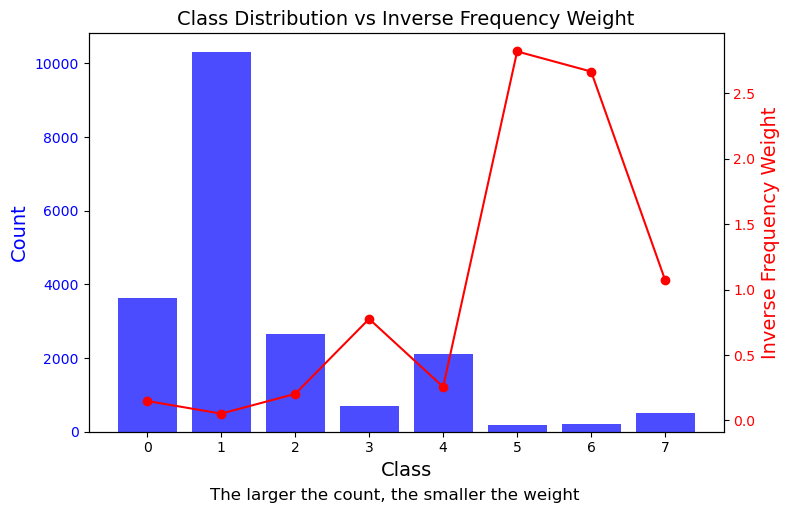

In [20]:
# Counts (left axis)
labels = counts.index.tolist()
counts_values = counts.values
weights_values = class_weights.cpu().numpy()

fig, ax1 = plt.subplots(figsize=(8, 5))

# Counts (left axis) - BLUE
bars = ax1.bar(labels, counts_values, color='blue', alpha=0.7)
ax1.set_xlabel("Class", fontsize = 14)
ax1.set_ylabel("Count", color='blue', fontsize = 14)
ax1.tick_params(axis='y', labelcolor='blue')

ax1.set_title("Class Distribution vs Inverse Frequency Weight", fontsize = 14)

# Weights (right axis) - RED
ax2 = ax1.twinx()
ax2.plot(labels, weights_values, color='red', marker='o')
ax2.set_ylabel("Inverse Frequency Weight", color='red', fontsize = 14)
ax2.tick_params(axis='y', labelcolor='red')

# Add annotation below x-axis label
fig.text(
    0.5, -0.01,
    "The larger the count, the smaller the weight",
    ha='center',
    fontsize=12
)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### TRAINING LOOP - run train_one_epoch for each epoch

In [21]:
#os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
# create tracked experiment run with labeled hyperparameters so you can analyze and compare results later

# entity → team/org/account in wandb
# project → folder for related experiments
# Run name → important for comparisons

# config={ ... } → logs hyperparameters:
#     model settings (architecture, pretrained, freeze_bb)
#     training settings (lr, batch_size, epochs)
#     early stopping (patience, min_delta)
#     reproducibility (seed)

# Stored so you can:
#     compare runs side-by-side
#     filter experiments (e.g., “show only focal loss runs”)
#     Reproduce results later

wandb.init(
    entity="vrb9e-university-of-virginia-school-of-data-science",
    project="ISIC2019",
    name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
    config={
        "architecture":  Config["architecture"],
        "loss_fn":       Config["loss_fn"],
        "augmentation":  Config["augmentation"],
        "pretrained":    Config["pretrained"],
        "freeze_bb":     Config["freeze_bb"],
        "img_size":      Config["img_size"],
        "batch_size":    Config["batch_size"],
        "epochs":        Config["epochs"],
        "lr":            Config["lr"],
        "val_split":     Config["val_split"],
        "patience":      Config["patience"],
        "dropout":       Config["dropout"],
        "seed":          Config["seed"],
    }
)


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING LOOP  ChaptGPT assist with extended metric logging
# ─────────────────────────────────────────────────────────────────────────────
model     = build_model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config["lr"])
scheduler = CosineAnnealingLR(optimizer, T_max=Config["epochs"], eta_min=1e-6)

best_bacc, best_epoch, no_improve = -1, 0, 0
history   = []
os.makedirs(CKPT_DIR, exist_ok=True)
ckpt_path = os.path.join(CKPT_DIR, "mobilenet_v3_small_best.pt")

logger.info(f"\nTraining | pretrained={Config['pretrained']} | loss={Config['loss_fn']}\n")
t0 = time.time()

for epoch in range(1, Config["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)

    (acc, bacc,
     sensitivity, specificity,
     precision_per, recall_per, f1_per,
     auc_per_class,
     cm,
     agg) = evaluate(model, val_loader, device)

    auc_macro = np.nanmean(list(auc_per_class.values()))

    # ── W&B log dict ──────────────────────────────────────────────────────────
    log_dict = {
        "epoch":                      epoch,
        # core
        "train/loss":                 train_loss,
        "val/acc":                    acc,
        "val/bacc":                   bacc,
        # macro aggregate
        "val/sensitivity_macro":      sensitivity.mean(),
        "val/specificity_macro":      specificity.mean(),
        "val/precision_macro":        agg["macro_precision"],
        "val/recall_macro":           agg["macro_recall"],
        "val/f1_macro":               agg["macro_f1"],
        "val/auc_macro":              auc_macro,
        # weighted aggregate
        "val/precision_weighted":     agg["wtd_precision"],
        "val/recall_weighted":        agg["wtd_recall"],
        "val/f1_weighted":            agg["wtd_f1"],
    }

    for i, cls in enumerate(Config["classes"]):
        log_dict[f"val/sensitivity_{cls}"]  = sensitivity[i]
        log_dict[f"val/specificity_{cls}"]  = specificity[i]
        log_dict[f"val/precision_{cls}"]    = precision_per[i]
        log_dict[f"val/recall_{cls}"]       = recall_per[i]
        log_dict[f"val/f1_{cls}"]           = f1_per[i]
        log_dict[f"val/auc_{cls}"]          = auc_per_class[cls]

    wandb.log(log_dict)

    # ── history list ──────────────────────────────────────────────────────────
    history.append({
        "epoch":              epoch,
        "train_loss":         train_loss,
        "val_acc":            acc,
        "val_bacc":           bacc,
        "val_sens":           float(sensitivity.mean()),
        "val_spec":           float(specificity.mean()),
        "val_precision_macro":float(agg["macro_precision"]),
        "val_recall_macro":   float(agg["macro_recall"]),
        "val_f1_macro":       float(agg["macro_f1"]),
        "val_precision_wtd":  float(agg["wtd_precision"]),
        "val_recall_wtd":     float(agg["wtd_recall"]),
        "val_f1_wtd":         float(agg["wtd_f1"]),
        "val_auc":            float(auc_macro),
    })

    # ── console output ────────────────────────────────────────────────────────
    logger.info(
        f"Epoch {epoch:3d}/{Config['epochs']} | loss={train_loss:.4f} | "
        f"acc={acc:.4f} | bacc={bacc:.4f} | "
        f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
        f"prec={agg['macro_precision']:.4f} | rec={agg['macro_recall']:.4f} | "
        f"f1={agg['macro_f1']:.4f} | auc={auc_macro:.4f}"
    )

    scheduler.step()

    # ── early stopping (min_delta guard, same as original) ────────────────────
    if bacc > best_bacc + Config.get("min_delta", 0.001):
        best_bacc, best_epoch = bacc, epoch
        no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        logger.info("  saved")
    else:
        no_improve += 1
        logger.info(f"  (no improve {no_improve}/{Config['patience']})")

    if no_improve >= Config["patience"]:
        logger.info(f"\nEarly stopping at epoch {epoch}.")
        break

# ── Final per-class AUC summary ───────────────────────────────────────────────
logger.info("\nPer-class AUC:")
for cls in Config["classes"]:
    logger.info(f"  {cls}: {auc_per_class.get(cls, float('nan')):.4f} | ")
logger.info("")

logger.info(f"\nDone in {(time.time()-t0)/60:.1f} min")
logger.info(f"Best  | epoch={best_epoch} | bacc={best_bacc:.4f}")
logger.info(
    f"Final | acc={acc:.4f} | bacc={bacc:.4f} | "
    f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
    f"prec_macro={agg['macro_precision']:.4f} | rec_macro={agg['macro_recall']:.4f} | "
    f"f1_macro={agg['macro_f1']:.4f} | "
    f"prec_wtd={agg['wtd_precision']:.4f} | rec_wtd={agg['wtd_recall']:.4f} | "
    f"f1_wtd={agg['wtd_f1']:.4f} | auc={auc_macro:.4f}"
)

# ── Confusion matrix (printed + plotted + saved) ──────────────────────────────
cm_save = os.path.join(CKPT_DIR, "confusion_matrix_final.png")
plot_confusion_matrix(cm, Config["classes"],
                      title="Confusion Matrix — Final Epoch",
                      save_path=cm_save)

# Re-evaluate best checkpoint for its confusion matrix
model.load_state_dict(torch.load(ckpt_path, map_location=device))
(_, _,
 sensitivity, specificity,
 precision_per, recall_per, f1_per,
 auc_per_class, cm_best, agg) = evaluate(model, val_loader, device)

cm_best_save = os.path.join(CKPT_DIR, "confusion_matrix_best.png")
plot_confusion_matrix(cm_best, Config["classes"],
                      title=f"Confusion Matrix — Best Epoch ({best_epoch})",
                      save_path=cm_best_save)

# ── Save history ──────────────────────────────────────────────────────────────
history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"History saved to {history_path}")

2026-04-28 14:41:38,308 | INFO | 
Training | pretrained=True | loss=focal



KeyboardInterrupt: 

### Epoch run summary statistics

In [ ]:
logger.info(f"\nDone in {(time.time()-t0)/60:.1f} min")

logger.info(f"Best   | epoch={best_epoch} | bacc={best_bacc:.4f}")
logger.info(f"Final  | acc={acc:.4f} | bacc={bacc:.4f} | "
      f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
      f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}")

# print AUC after last epoch
logger.info("\nPer-class AUC:")
for cls in Config["classes"]:
    auc_val = auc_per_class.get(cls, float("nan"))
    logger.info(f"  {cls}: {auc_val:.4f} | ")
logger.info("")

history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"\nHistory saved to {history_path}")


### Weights and Bias Metrics

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# W&B BENCHMARK BLOCK  ChatGPT assist with extended summary
# ─────────────────────────────────────────────────────────────────────────────
def print_benchmark(model, label="Model"):
    params_total     = sum(p.numel() for p in model.parameters())
    params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb          = params_total * 4 / 1024 ** 2  # float32

    # Inference speed
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        start = torch.cuda.Event(enable_timing=True)
        end   = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(50):
            model(dummy)
        end.record()
        torch.cuda.synchronize()
        inference_ms = start.elapsed_time(end) / 50

    # GFLOPs (requires thop)
    try:
        from thop import profile
        flops, _ = profile(model, inputs=(dummy,), verbose=False)
        gflops = flops / 1e9
    except Exception:
        gflops = None

    bench = {
        "params_total":     params_total,
        "params_trainable": params_trainable,
        "size_mb":          round(size_mb, 2),
        "inference_ms":     round(inference_ms, 2),
        "gflops":           round(gflops, 4) if gflops else None,
    }
    logger.info(f"\n=== Benchmark: {label} ===")
    for k, v in bench.items():
        logger.info(f"  {k}: {v}")
    return bench


# Final best-checkpoint evaluation + W&B summary
(acc_best, bacc_best,
 sensitivity_best, specificity_best,
 precision_best, recall_best, f1_best,
 auc_best, cm_best, agg_best) = evaluate(model, val_loader, device)

auc_macro_best = np.nanmean(list(auc_best.values()))

bench = print_benchmark(
    model,
    label=f"mobilenet_v3_small ({Config['loss_fn']}, aug={Config['augmentation']})"
)

# log benchmark + best-epoch metrics to W&B summary
wandb.summary.update({
    "benchmark/params_total":     bench["params_total"],
    "benchmark/params_trainable": bench["params_trainable"],
    "benchmark/size_mb":          bench["size_mb"],
    "benchmark/inference_ms":     bench["inference_ms"],
    "benchmark/gflops":           bench["gflops"],
    "best_epoch":                 best_epoch,
    "best_val_bacc":              best_bacc,
    # core best-epoch metrics
    "best/acc":                   acc_best,
    "best/bacc":                  bacc_best,
    "best/sensitivity_macro":     float(sensitivity_best.mean()),
    "best/specificity_macro":     float(specificity_best.mean()),
    "best/precision_macro":       float(agg_best["macro_precision"]),
    "best/recall_macro":          float(agg_best["macro_recall"]),
    "best/f1_macro":              float(agg_best["macro_f1"]),
    "best/precision_weighted":    float(agg_best["wtd_precision"]),
    "best/recall_weighted":       float(agg_best["wtd_recall"]),
    "best/f1_weighted":           float(agg_best["wtd_f1"]),
    "best/auc_macro":             float(auc_macro_best),
})

# per-class best-epoch metrics to W&B summary
for i, cls in enumerate(Config["classes"]):
    wandb.summary[f"best/sensitivity_{cls}"]  = float(sensitivity_best[i])
    wandb.summary[f"best/specificity_{cls}"]  = float(specificity_best[i])
    wandb.summary[f"best/precision_{cls}"]    = float(precision_best[i])
    wandb.summary[f"best/recall_{cls}"]       = float(recall_best[i])
    wandb.summary[f"best/f1_{cls}"]           = float(f1_best[i])
    wandb.summary[f"best/auc_{cls}"]          = float(auc_best.get(cls, float("nan")))

# log confusion-matrix images to W&B
wandb.log({
    "confusion_matrix/final": wandb.Image(cm_save),
    "confusion_matrix/best":  wandb.Image(cm_best_save),
})

artifact = wandb.Artifact(
    name=f"mobilenet_v3_small_{Config['loss_fn']}_{Config['augmentation']}",
    type="model",
    description=f"Best checkpoint — val BACC {best_bacc:.4f} @ epoch {best_epoch}",
)
artifact.add_file(ckpt_path)
wandb.log_artifact(artifact)
logger.info("Checkpoint artifact logged to W&B")

wandb.finish()
logger.info("W&B run finished.")


# DON'T KNOWS IF WE NEED THIS CODE
# History saving
history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"History saved to {history_path}")

In [ ]:
import wandb
api = wandb.Api()
ENTITY  = "vrb9e-university-of-virginia-school-of-data-science"
PROJECT = "ISIC2019"
runs = api.runs(f"{ENTITY}/{PROJECT}")

def parse_name(name):
    pretrained = True if "pretrainedTrue" in name else (False if "pretrainedFalse" in name else None)
    augmentation = next((a for a in ["standard", "geometric", "color", "none"] if a in name), None)
    loss_fn = next((l for l in ["weighted_ce", "focal", "ce"] if l in name), None)  # weighted_ce before ce
    arch = next((a for a in ["mobilenet_v3_small", "mobilenetv3_small", "resnet50", "efficientnet_b0"] if a in name), None)
    return arch, loss_fn, augmentation, pretrained

rows = []
for run in runs:
    parsed_arch, parsed_loss, parsed_aug, parsed_pretrained = parse_name(run.name)
    config = run.config

    row = {
        "run_id":       run.id,
        "name":         run.name,
        # config first, fall back to name parsing
        "architecture": config.get("architecture") or parsed_arch,
        "loss_fn":      config.get("loss_fn")      or parsed_loss,
        "augmentation": config.get("augmentation") or parsed_aug,
        "pretrained":   config.get("pretrained")   if config.get("pretrained") is not None else parsed_pretrained,
        "freeze_bb":    config.get("freeze_bb"),
        "best_bacc":    run.summary.get("best_val_bacc"),
        "best_f1":      run.summary.get("best/f1_macro"),
        "best_auc":     run.summary.get("best/auc_macro"),
    }
    rows.append(row)

df = pd.DataFrame(rows)
df = df.dropna(subset=["best_bacc"])
df = df.sort_values(by="best_bacc", ascending=False)
df.to_csv("all_runs_summary.csv", index=False)
logger.info("Saved: all_runs_summary.csv")

# Save per-run metrics for the current arch
metrics_dataframe = run.history()

arch_map = {
    "mobilenetv3_small":   "mbnt_",
    "resnet50":            "resn_",
    "efficientnet_b0":     "eff0_",
}
arch = Config.get("architecture", "")

arch_tag = arch_map.get(arch, "unkn_")

if Config["freeze_bb"] is True:
    freeze_tag = "freezeBB_"
elif Config["freeze_bb"] == "partial":
    freeze_tag = "partial_"
else:
    freeze_tag = "noFreezeBB_"

loss_tag = Config["loss_fn"]

filename = f"metrics_{arch_tag}{freeze_tag}{loss_tag}.csv"
metrics_dataframe.to_csv(filename)
logger.info(f"Saved metrics to: {filename}")


In [ ]:
import wandb
import pandas as pd

api = wandb.Api()

ENTITY  = "vrb9e-university-of-virginia-school-of-data-science"
PROJECT = "ISIC2019"

runs = api.runs(f"{ENTITY}/{PROJECT}")

for run in runs:
    row = {}

    row["run_id"] = run.id
    row["name"]   = run.name

    # ── Parse name as fallback: arch_lossfn_augmentation_pretrainedBool ──
    name_parts = run.name.split("_")
    # name format: mobilenetv3_small_focal_standard_pretrainedTrue
    # or:          mobilenet_v3_small_weighted_ce_standard_pretrainedTrue

    def parse_name(name):
        """Extract arch, loss_fn, augmentation, pretrained from run name."""
        pretrained = None
        if "pretrainedTrue" in name:
            pretrained = True
        elif "pretrainedFalse" in name:
            pretrained = False

        augmentation = None
        for aug in ["standard", "geometric", "color", "none"]:
            if aug in name:
                augmentation = aug
                break

        loss_fn = None
        for loss in ["weighted_ce", "focal", "ce"]:   # order matters: weighted_ce before ce
            if loss in name:
                loss_fn = loss
                break

        arch = None
        for a in ["mobilenetv3_small", "mobilenet_v3_small", "resnet50", "efficientnet_b0"]:
            if a in name:
                arch = a
                break

        return arch, loss_fn, augmentation, pretrained

    parsed_arch, parsed_loss, parsed_aug, parsed_pretrained = parse_name(run.name)

    config = run.config
    row["architecture"] = config.get("architecture") or parsed_arch
    row["loss_fn"]      = config.get("loss_fn")      or parsed_loss
    row["augmentation"] = config.get("augmentation") or parsed_aug
    row["pretrained"]   = config.get("pretrained")   if config.get("pretrained") is not None else parsed_pretrained
    row["freeze_bb"]    = config.get("freeze_bb")
    row["lr"]           = config.get("lr")
    row["batch_size"]   = config.get("batch_size")

    summary = run.summary
    row["best_bacc"]        = summary.get("best_val_bacc")
    row["best_acc"]         = summary.get("best/acc")
    row["best_f1_macro"]    = summary.get("best/f1_macro")
    row["best_auc_macro"]   = summary.get("best/auc_macro")
    row["best_precision"]   = summary.get("best/precision_macro")
    row["best_recall"]      = summary.get("best/recall_macro")
    row["params"]           = summary.get("benchmark/params_total")
    row["inference_ms"]     = summary.get("benchmark/inference_ms")

    rows.append(row)

rows = []

for run in runs:
    row = {}

    # ── Basic info ─────────────────────────────
    row["run_id"]   = run.id
    row["name"]     = run.name
    row["state"]    = run.state

    # ── Config (hyperparameters) ───────────────
    config = run.config
    row["architecture"] = config.get("architecture")
    row["loss_fn"]      = config.get("loss_fn")
    row["augmentation"] = config.get("augmentation")
    row["pretrained"]   = config.get("pretrained")
    row["freeze_bb"]    = config.get("freeze_bb")
    row["lr"]           = config.get("lr")
    row["batch_size"]   = config.get("batch_size")

    # ── Summary metrics (BEST values you logged) ──
    summary = run.summary

    row["best_bacc"]        = summary.get("best_val_bacc")
    row["best_acc"]         = summary.get("best/acc")
    row["best_f1_macro"]    = summary.get("best/f1_macro")
    row["best_auc_macro"]   = summary.get("best/auc_macro")
    row["best_precision"]   = summary.get("best/precision_macro")
    row["best_recall"]      = summary.get("best/recall_macro")

    # optional extras
    row["params"]           = summary.get("benchmark/params_total")
    row["inference_ms"]     = summary.get("benchmark/inference_ms")

    rows.append(row)

# ── Convert to DataFrame ───────────────────────
df = pd.DataFrame(rows)

# Sort by best performance
df = df.sort_values(by="best_bacc", ascending=False)

# Save
df.to_csv("all_runs_summary.csv", index=False)

logger.info("Saved: all_runs_summary.csv")
logger.info(df.head())

In [ ]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# 1. LOAD RUNS FROM W&B
# ─────────────────────────────────────────────
api = wandb.Api()

ENTITY  = "vrb9e-university-of-virginia-school-of-data-science"
PROJECT = "ISIC2019"

runs = api.runs(f"{ENTITY}/{PROJECT}")

rows = []

for run in runs:
    row = {}

    row["run_id"] = run.id
    row["name"]   = run.name

    # ── Parse name as fallback: arch_lossfn_augmentation_pretrainedBool ──
    name_parts = run.name.split("_")
    # name format: mobilenetv3_small_focal_standard_pretrainedTrue
    # or:          mobilenet_v3_small_weighted_ce_standard_pretrainedTrue

    def parse_name(name):
        """Extract arch, loss_fn, augmentation, pretrained from run name."""
        pretrained = None
        if "pretrainedTrue" in name:
            pretrained = True
        elif "pretrainedFalse" in name:
            pretrained = False

        augmentation = None
        for aug in ["standard", "geometric", "color", "none"]:
            if aug in name:
                augmentation = aug
                break

        loss_fn = None
        for loss in ["weighted_ce", "focal", "ce"]:   # order matters: weighted_ce before ce
            if loss in name:
                loss_fn = loss
                break

        arch = None
        for a in ["mobilenetv3_small", "mobilenet_v3_small", "resnet50", "efficientnet_b0"]:
            if a in name:
                arch = a
                break

        return arch, loss_fn, augmentation, pretrained

    parsed_arch, parsed_loss, parsed_aug, parsed_pretrained = parse_name(run.name)

    config = run.config
    row["architecture"] = config.get("architecture") or parsed_arch
    row["loss_fn"]      = config.get("loss_fn")      or parsed_loss
    row["augmentation"] = config.get("augmentation") or parsed_aug
    row["pretrained"]   = config.get("pretrained")   if config.get("pretrained") is not None else parsed_pretrained
    row["freeze_bb"]    = config.get("freeze_bb")
    row["lr"]           = config.get("lr")
    row["batch_size"]   = config.get("batch_size")

    summary = run.summary
    row["best_bacc"]        = summary.get("best_val_bacc")
    row["best_acc"]         = summary.get("best/acc")
    row["best_f1_macro"]    = summary.get("best/f1_macro")
    row["best_auc_macro"]   = summary.get("best/auc_macro")
    row["best_precision"]   = summary.get("best/precision_macro")
    row["best_recall"]      = summary.get("best/recall_macro")
    row["params"]           = summary.get("benchmark/params_total")
    row["inference_ms"]     = summary.get("benchmark/inference_ms")

    rows.append(row)

df = pd.DataFrame(rows)

# Clean: drop runs with missing metrics
df = df.dropna(subset=["best_bacc"])

logger.info("Data loaded:")
logger.info(df.head())